<a href="https://colab.research.google.com/github/ThisalFernando/Fake-Real-News-Detection/blob/Logistic_regression/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fake-Real News Detection using Supervised Machine Learning Algorithm (Logistic Regression)**

### Student No: IT22244802

### Student Name: Fernando P. T. V. A



I have implemented the fake-real news detection model using Logistic regression Alrogithm using the publicly available, merged dataset which has been retrieved from the Kaggle


Link for the dataset: https://drive.google.com/file/d/1aGVDidP_zjIZKqXaih06IsiWi8mA3okK/view?usp=drive_link







## **Step 01: Mount Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Step 02: Import the requiured libraries**

In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

## **Step 03: Load the Dataset**

In [3]:
file_path = "/content/drive/MyDrive/Colab Notebooks/ML Assignment - Fake-Real news detection/improved_fake_news_dataset2.csv"
df = pd.read_csv(file_path)

df.head()

,id,title,text,label
0,156735,NaN,Embargo on Phillipines - withdraw our military...,1
1,212890,Especially sea lay son hear.,too win central main bag save common she famil...,1
2,183407,Russian oil giant Rosneft to restore Romanov p...,Russian oil giant Rosneft to restore Romanov p...,1
3,199095,NaN,the club world cup is here our representative ...,0
4,228061,NaN,"the ismaili club s board of directors, headed ...",1


## **Step 04: Understand Dataset**

In [4]:
print(df.columns)
print(df.shape)
df.info()

Index(['id', 'title', 'text', 'label'], dtype='object')
(123954, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123954 entries, 0 to 123953
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      123954 non-null  int64 
 1   title   90502 non-null   object
 2   text    123954 non-null  object
 3   label   123954 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 3.8+ MB


In [5]:
X = df['text']
y = df['label']

In [6]:
df = df.dropna(subset=['text', 'label'])

## **Step 05: Text Preprocessing**

In [18]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

X = X.apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **Step 06: Train-Test Split**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **Step 07: TF-IDF Vectorization**

In [36]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.75,
    min_df=2,
    ngram_range=(1,2),
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## **Step 08: Train Logistic Regression Model**

In [37]:
model = LogisticRegression(max_iter=2000, C=2, solver='liblinear', class_weight='balanced')
model.fit(X_train_tfidf, y_train)

LogisticRegression(C=2, class_weight='balanced', max_iter=2000,
                   solver='liblinear')

## **Step 09: Predictions**

In [38]:
y_pred = model.predict(X_test_tfidf)

In [39]:
def predict_news(news_text):
    # Clean the text (same preprocessing!)
    cleaned = clean_text(news_text)

    # Convert to TF-IDF
    vectorized = vectorizer.transform([cleaned])

    # Predict
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]

    # Convert label to readable output
    if prediction == 1:
        return f"REAL NEWS 🟢 (Confidence: {probability[1]:.2f})"
    else:
        return f"FAKE NEWS 🔴 (Confidence: {probability[0]:.2f})"

### Test for real news

In [40]:
news = "Government announces new economic policy to reduce inflation."

result = predict_news(news)
print("Prediction:", result)

Prediction: REAL NEWS 🟢 (Confidence: 0.85)


### Test for fake news

In [41]:
news = "Aliens have landed in New York and taken control of the city."

print("Prediction:", predict_news(news))

Prediction: FAKE NEWS 🔴 (Confidence: 0.63)


## **Step 10: Evaluation**

### Model Accuracy with Classification Report

In [42]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8584970352143924

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86     12333
           1       0.88      0.83      0.85     12458

    accuracy                           0.86     24791
   macro avg       0.86      0.86      0.86     24791
weighted avg       0.86      0.86      0.86     24791



### Confusion Matrix

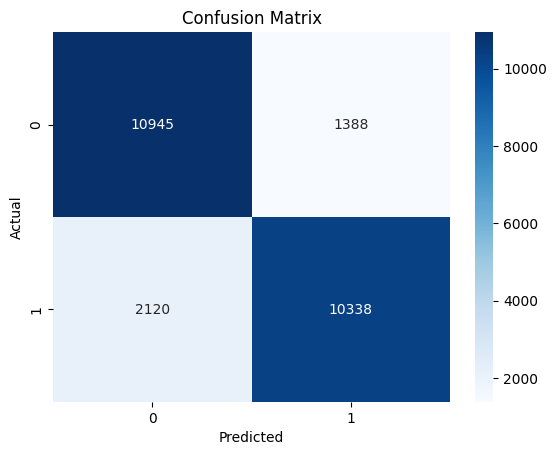

In [43]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### ROC Curve & AUC Score

AUC Score: 0.9477531394319748



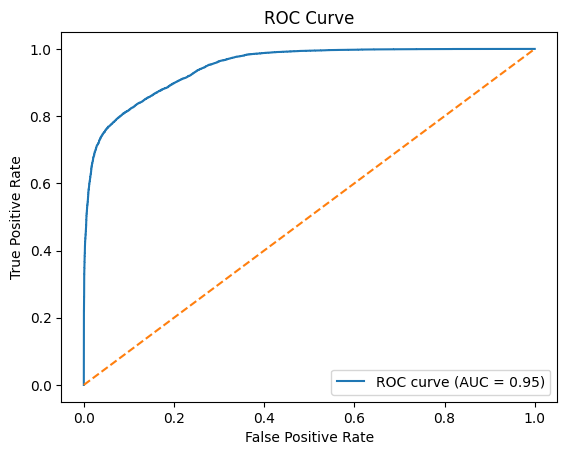

In [44]:
# Get probability scores
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC score
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)
print()

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # Random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()